# ConsDB + EFD Join — LSSTCam Exploration

Joins **ConsDB** (`cdb_lsstcam`) science-exposure records to **EFD** telemetry,
building on `ESS_Wind_vs_DomePointing.ipynb`.

For each science exposure we combine:

| Source | Data |
|---|---|
| `cdb_lsstcam.exposure` | pointing, wind summary, filter, timing |
| `cdb_lsstcam.visit1_quicklook` | PSF σ, effective time, seeing, Zernikes, guider |
| `cdb_lsstcam.exposure_quicklook` | mount jitter, image degradation |
| EFD `lsst.sal.ESS.airFlow` index 301 | 20 Hz outside wind speed / direction |
| EFD `lsst.sal.MTDome.azimuth` | dome azimuth (not in ConsDB schema) |
| EFD `lsst.sal.MTDome.apertureShutter` | shutter state |
| EFD `lsst.sal.ESS.airTurbulence` indices 110, 123–126 | inside turbulence |

## Database
Host: `usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu`  
Database: `exposurelog`  
Credentials: `~/.lsst/postgres-credentials.txt` (pgpass format)  
No RSP bearer token required from SLAC compute nodes.

## Imports

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [41]:
# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE  = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST  = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB    = "exposurelog"
CONSDB_USER  = "usdf"
SCHEMA       = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) < 5:
                continue
            h, db, u_ = parts[0], parts[2], parts[3]
            pwd = ":".join(parts[4:])
            if h == host and db == database and u_ == user:
                return pwd
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

# Verify connection and available schemas
schemas = consdb_query(
    "SELECT schema_name FROM information_schema.schemata "
    "WHERE schema_name LIKE 'cdb_%' ORDER BY 1"
)
print("ConsDB schemas:")
display(schemas)

# ── Time window (matches ESS_Wind_vs_DomePointing.ipynb) ─────────────────────
t_end   = Time("2026-03-15T05:00:00", scale="utc")
t_start = t_end - TimeDelta(10 * u.week)
day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))
print(f"\nTime window: {t_start.iso}  to  {t_end.iso}")
print(f"day_obs:     {day_obs_start}  to  {day_obs_end}")

# ── EFD ───────────────────────────────────────────────────────────────────────
EFD_ALIAS        = "usdf_efd"
flow_topic       = "lsst.sal.ESS.airFlow"
turb_topic       = "lsst.sal.ESS.airTurbulence"
dome_topic       = "lsst.sal.MTDome.azimuth"
shutter_topic    = "lsst.sal.MTDome.apertureShutter"
weather_index    = 301          # calibration hill weather station
shutter_threshold = 95.0        # % open to count as "open"

ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring -X/-Y",
    124: "Top Ring +X/-Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring -X/+Y",
}

# Wind speed bin thresholds (m/s) — matches parent notebook
wind_speed_bins   = [0, 3, 6, 9, 12, np.inf]
wind_speed_labels = ["0-3 m/s", "3-6 m/s", "6-9 m/s", "9-12 m/s", ">12 m/s"]
wind_speed_colors = ["steelblue", "mediumseagreen", "goldenrod", "tomato", "mediumpurple"]

# ── Mount jitter clip ─────────────────────────────────────────────────────────
MOUNT_JITTER_MIN = 0.0   # arcsec — exclude non-physical zero / negative values
MOUNT_JITTER_MAX = 1.0   # arcsec — exclude outliers / bad data above this threshold

ConsDB schemas:


,schema_name
0,cdb_latiss
1,cdb_lsstcam
2,cdb_lsstcomcam
3,cdb_lsstcomcamsim
4,cdb_startrackerfast
5,cdb_startrackernarrow
6,cdb_startrackerwide



Time window: 2026-01-04 05:00:00.000  to  2026-03-15 05:00:00.000
day_obs:     20260104  to  20260315


## 1. ConsDB Schema Exploration

Inspect the LSSTCam schema before querying — column names differ from the older
LATISS schema and from the REST API documentation.

In [42]:
# Tables in cdb_lsstcam
tables = consdb_query(f"""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = '{SCHEMA}'
    ORDER BY table_name
""")
print(f"Tables in {SCHEMA}:")
display(tables)

Tables in cdb_lsstcam:


,table_name
0,ccdexposure
1,ccdexposure_camera
2,ccdexposure_flexdata
3,ccdexposure_flexdata_schema
4,ccdexposure_quicklook
5,ccdvisit1
6,ccdvisit1_quicklook
7,exposure
8,exposure_flexdata
9,exposure_flexdata_schema


In [43]:
# Column listing for key tables
for tbl in ["exposure", "exposure_quicklook", "visit1_quicklook"]:
    cols = consdb_query(f"""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = '{SCHEMA}' AND table_name = '{tbl}'
        ORDER BY ordinal_position
    """)
    print(f"\n[{SCHEMA}.{tbl}] — {len(cols)} columns:")
    display(cols)


[cdb_lsstcam.exposure] — 51 columns:


,column_name,data_type
0,exposure_id,bigint
1,exposure_name,character varying
2,controller,character varying
3,day_obs,integer
4,seq_num,integer
5,physical_filter,character varying
6,band,character varying
7,s_ra,double precision
8,s_dec,double precision
9,sky_rotation,double precision



[cdb_lsstcam.exposure_quicklook] — 16 columns:


,column_name,data_type
0,exposure_id,bigint
1,day_obs,integer
2,seq_num,integer
3,postisr_pixel_median_median,double precision
4,postisr_pixel_median_mean,double precision
5,postisr_pixel_median_max,double precision
6,mount_motion_image_degradation,double precision
7,mount_motion_image_degradation_az,double precision
8,mount_motion_image_degradation_rot,double precision
9,mount_jitter_rms,double precision



[cdb_lsstcam.visit1_quicklook] — 166 columns:


,column_name,data_type
0,visit_id,bigint
1,day_obs,integer
2,seq_num,integer
3,n_inputs,integer
4,pixel_scale_min,double precision
...,...,...
161,guider_roi_rows,double precision
162,guider_psf_fwhm,double precision
163,astrom_ra,double precision
164,astrom_dec,double precision


In [44]:
# Data summary: img_type distribution and date range
print("img_type counts:")
display(consdb_query(f"""
    SELECT img_type, count(*) AS n
    FROM {SCHEMA}.exposure
    GROUP BY img_type ORDER BY n DESC
"""))

print("\nScience exposures date range:")
display(consdb_query(f"""
    SELECT min(day_obs), max(day_obs), count(*) AS n
    FROM {SCHEMA}.exposure
    WHERE img_type = 'science'
"""))

print("\nquicklook coverage (exposures with visit1_quicklook):")
display(consdb_query(f"""
    SELECT count(DISTINCT e.exposure_id) AS n_with_quicklook
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
"""))

img_type counts:


,img_type,n
0,science,56424
1,acq,32742
2,flat,28403
3,bias,12995
4,dark,12286
5,cwfs,5610
6,engtest,2065
7,focus,176
8,indome,26
9,test,1



Science exposures date range:


,min,max,n
0,20250412,20260330,56424



quicklook coverage (exposures with visit1_quicklook):


,n_with_quicklook
0,18013


## 2. Fetch Science Exposures + Quicklook from ConsDB

### Column name changes vs LATISS / REST API docs

| `cdb_lsstcam` column | LATISS / old name | Notes |
|---|---|---|
| `img_type = 'science'` | `imgtype = 'OBJECT'` | lowercase in lsstcam |
| `obs_start` / `obs_start_mjd` | `obsstart` / `obsstartmjd` | now matches REST API |
| `exp_time` | `exptime` | |
| `s_ra` / `s_dec` | `ra` / `decl` | now matches REST API |
| `sky_rotation` | `skyrotation` | |
| `air_temp` | `airtemp` | |
| `exp_midpt` | `expmidpt` | |
| *(no dome_azimuth)* | `dome_azimuth` | fetch from EFD MTDome.azimuth |

`visit1_quicklook` adds PSF σ, effective time, seeing, Zernikes z4–z28, guider metrics.  
`exposure_quicklook` adds mount jitter and image degradation.

In [66]:
df_exp = consdb_query(f"""
    SELECT
        e.exposure_id,
        e.day_obs,
        e.seq_num,
        e.obs_start,
        e.obs_start_mjd,
        e.exp_time,
        e.airmass,
        e.s_ra,
        e.s_dec,
        e.sky_rotation,
        e.azimuth,
        e.altitude,
        e.wind_speed,
        e.wind_dir,
        e.dimm_seeing,
        e.air_temp,
        e.humidity,
        e.focus_z,
        e.vignette,
        e.can_see_sky,
        e.band,
        e.physical_filter,
        e.target_name,
        e.img_type,
        e.scheduler_note,
        -- visit1_quicklook: image quality metrics
        q.psf_sigma_median,
        q.seeing_zenith_500nm_median,
        q.eff_time_median,
        q.sky_bg_median,
        q.sky_noise_median,
        q.zero_point_median,
        q.stats_mag_lim_median,
        q.n_inputs,
        q.astrom_offset_mean_median,
        -- guider & AOS
        q.guider_psf_fwhm,
        q.guider_total_seeing,
        q.ringss_seeing,
        q.aos_fwhm,
        q.donut_blur_fwhm,
        -- Zernikes (tip/tilt removed; defocus = z4)
        q.z4, q.z5, q.z6, q.z7, q.z8, q.z9, q.z10, q.z11,
        -- mount (from exposure_quicklook)
        m.mount_motion_image_degradation,
        m.mount_motion_image_degradation_az,
        m.mount_motion_image_degradation_el,
        m.mount_jitter_rms,
        m.mount_jitter_rms_az,
        m.mount_jitter_rms_el,
        m.mount_jitter_rms_rot
    FROM {SCHEMA}.exposure e
    LEFT JOIN {SCHEMA}.visit1_quicklook  q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    LEFT JOIN {SCHEMA}.exposure_quicklook m ON m.day_obs = e.day_obs AND m.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
    ORDER BY e.obs_start_mjd
""")

# Attach UTC timezone to obs_start
df_exp["obs_start_utc"] = pd.to_datetime(df_exp["obs_start"], utc=True)
df_exp = df_exp.set_index("obs_start_utc")

print(f"Science exposures fetched : {len(df_exp)}")
print(f"Date range : {df_exp.index.min()} to {df_exp.index.max()}")
print(f"\nWith PSF sigma      : {df_exp['psf_sigma_median'].notna().sum()}")
print(f"With donut_blur_fwhm: {df_exp['donut_blur_fwhm'].notna().sum()}")
print(f"With aos_fwhm       : {df_exp['aos_fwhm'].notna().sum()}")
print(f"With mount jitter   : {df_exp['mount_jitter_rms'].notna().sum()}")
print(f"With wind speed     : {df_exp['wind_speed'].notna().sum()}")
df_exp.head()

Science exposures fetched : 18120
Date range : 2026-01-05 01:35:19.348000+00:00 to 2026-03-16 09:51:51.106000+00:00

With PSF sigma      : 18010
With donut_blur_fwhm: 17979
With aos_fwhm       : 17979
With mount jitter   : 5486
With wind speed     : 18120


,exposure_id,day_obs,seq_num,obs_start,obs_start_mjd,exp_time,airmass,s_ra,s_dec,sky_rotation,...,z9,z10,z11,mount_motion_image_degradation,mount_motion_image_degradation_az,mount_motion_image_degradation_el,mount_jitter_rms,mount_jitter_rms_az,mount_jitter_rms_el,mount_jitter_rms_rot
obs_start_utc,,,,,,,,,,,,,,,,,,,,,
2026-01-05 01:35:19.348000+00:00,2026010400103,20260104,103,2026-01-05 01:35:19.348,61045.066196,30.0,1.299352,9.633846,-44.186965,321.641165,...,None,None,None,0.004632,0.001205,0.004472,0.004854,0.001886,0.004472,0.115747
2026-01-05 01:35:59.200000+00:00,2026010400104,20260104,104,2026-01-05 01:35:59.200,61045.066657,30.0,1.299797,9.743351,-43.901028,318.771251,...,None,None,None,0.004600,0.001067,0.004475,0.004776,0.001669,0.004475,0.117157
2026-01-05 01:38:54.921000+00:00,2026010400105,20260104,105,2026-01-05 01:38:54.921,61045.068691,30.0,1.192605,35.805965,-4.837723,13.378381,...,None,None,None,0.005452,0.001801,0.005145,0.006114,0.003303,0.005145,0.160650
2026-01-05 01:39:37.656000+00:00,2026010400106,20260104,106,2026-01-05 01:39:37.656,61045.069186,30.0,1.195667,35.369614,-5.023338,10.036630,...,None,None,None,0.004902,0.001991,0.004479,0.005765,0.003629,0.004479,0.153465
2026-01-05 01:43:12.021000+00:00,2026010400107,20260104,107,2026-01-05 01:43:12.021,61045.071667,30.0,1.328522,9.516148,-44.042398,39.068702,...,None,None,None,0.004408,0.001110,0.004266,0.004587,0.001685,0.004266,0.111014


In [67]:
# Quick statistics
print("Band distribution:")
display(df_exp["band"].value_counts())

print("\nPSF sigma median (pixels):")
display(df_exp["psf_sigma_median"].describe())

print("\nWind speed (m/s):")
display(df_exp["wind_speed"].describe())

print("\nMount jitter RMS (arcsec):")
display(df_exp["mount_jitter_rms"].describe())

Band distribution:


band
i    5165
y    4975
z    3620
r    2556
g    1415
u     389
Name: count, dtype: int64


PSF sigma median (pixels):


count    18010.000000
mean         2.176078
std          0.479402
min          1.345827
25%          1.863593
50%          2.068617
75%          2.346610
max          7.701598
Name: psf_sigma_median, dtype: float64


Wind speed (m/s):


count    18120.000000
mean         3.267623
std          2.435216
min          0.000000
25%          1.417800
50%          2.919000
75%          4.753800
max         15.762600
Name: wind_speed, dtype: float64


Mount jitter RMS (arcsec):


count    5486.000000
mean        0.087471
std         3.289993
min         0.002856
25%         0.004878
50%         0.005652
75%         0.006782
max       189.586205
Name: mount_jitter_rms, dtype: float64

## 3. Fetch EFD Telemetry

Same topics as `ESS_Wind_vs_DomePointing.ipynb`:

| Topic | Index | Fields | Purpose |
|---|---|---|---|
| `lsst.sal.ESS.airFlow` | 301 | `speed`, `direction` | Outside wind |
| `lsst.sal.MTDome.azimuth` | — | `positionActual` | Dome azimuth (not in ConsDB) |
| `lsst.sal.MTDome.apertureShutter` | — | `positionActual0/1` | Shutter state |
| `lsst.sal.ESS.airTurbulence` | 110, 123–126 | `speedMagnitude`, `sonicTemperatureStdDev` | Inside turbulence |

In [68]:
efd_client = EfdClient(EFD_ALIAS)
print("Connected to EFD")

Connected to EFD


In [69]:
# Outside wind (ESS:301)
df_wind_raw = await efd_client.select_time_series(
    flow_topic,
    fields=["direction", "speed"],
    start=t_start,
    end=t_end,
    index=weather_index,
)
print(f"ESS:{weather_index} airFlow rows: {len(df_wind_raw)}")
df_wind_raw.head()

ESS:301 airFlow rows: 4675451


,direction,speed
2026-01-04 05:00:00.108768+00:00,153.479996,2.9190
2026-01-04 05:00:01.389559+00:00,152.964996,3.0024
2026-01-04 05:00:02.668901+00:00,152.080002,2.9190
2026-01-04 05:00:03.949131+00:00,152.095001,2.9190
2026-01-04 05:00:05.228424+00:00,152.100006,3.0858


In [70]:
# Dome azimuth — needed for relative wind pointing (not stored in cdb_lsstcam.exposure)
df_dome = await efd_client.select_time_series(
    dome_topic,
    fields="positionActual",
    start=t_start,
    end=t_end,
)
print(f"Dome azimuth rows: {len(df_dome)}")
df_dome.head()

Dome azimuth rows: 10160814


,positionActual
2026-01-04 05:00:00.599835+00:00,180.779160
2026-01-04 05:00:00.812747+00:00,180.794601
2026-01-04 05:00:01.742826+00:00,181.190689
2026-01-04 05:00:01.969561+00:00,181.369659
2026-01-04 05:00:02.181835+00:00,181.611511


In [71]:
# Aperture shutter (to flag shutter-open science exposures)
df_shutter = await efd_client.select_time_series(
    shutter_topic,
    fields=["positionActual0", "positionActual1"],
    start=t_start,
    end=t_end,
)
print(f"Shutter rows: {len(df_shutter)}")
df_shutter.head()

Shutter rows: 3992780


,positionActual0,positionActual1
2026-01-04 05:00:01.020764+00:00,100.029999,100.010002
2026-01-04 05:00:02.382498+00:00,100.029999,100.010002
2026-01-04 05:00:03.649575+00:00,100.029999,100.010002
2026-01-04 05:00:05.109426+00:00,100.029999,100.010002
2026-01-04 05:00:06.249842+00:00,100.029999,100.010002


In [72]:
# Inside turbulence sensors
ess_data = {}
for idx, label in ess_sensors.items():
    df = await efd_client.select_time_series(
        turb_topic,
        fields=["speedMagnitude", "sonicTemperatureStdDev"],
        start=t_start,
        end=t_end,
        index=idx,
    )
    ess_data[idx] = df
    print(f"  [{idx}] {label:20s}  rows={len(df)}")

  [110] TMA Platform          rows=1182672
  [123] Top Ring -X/-Y        rows=741336
  [124] Top Ring +X/-Y        rows=742032
  [125] Top Ring +X/+Y        rows=742679
  [126] Top Ring -X/+Y        rows=742685


## 4. Join EFD Telemetry to ConsDB Exposures

For each science exposure we interpolate or `merge_asof` the EFD streams to the
exposure midpoint timestamp.

- **Dome azimuth**: linear interpolation (dense 20 Hz stream, smooth motion)
- **Wind speed/direction**: `merge_asof` ±3 min
- **Inside turbulence**: resample each sensor to 1 s, then `merge_asof` ±5 s
- **Shutter open**: both doors > 95 % at exposure midpoint

In [73]:
def wrap_angle(a):
    """Wrap angle to [-180, 180] degrees."""
    return ((a + 180.0) % 360.0) - 180.0


# Work in seconds-since-epoch for interpolation
def to_epoch(ts):
    return ts.astype(np.int64) / 1e9

# Exposure midpoints (use obs_start + exp_time/2 — obs_start is index)
exp_midpt_utc = df_exp.index + pd.to_timedelta(df_exp["exp_time"] / 2, unit="s")
exp_epoch     = to_epoch(exp_midpt_utc)

# ── Dome azimuth at exposure midpoint (linear interp) ────────────────────────
dome_epoch = to_epoch(df_dome.index)
dome_az_at_exp = np.interp(exp_epoch, dome_epoch, df_dome["positionActual"].values)
df_exp["dome_azimuth_efd"] = dome_az_at_exp

# ── Shutter state at exposure midpoint ───────────────────────────────────────
shut_epoch = to_epoch(df_shutter.index)
left_at_exp  = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual0"].values)
right_at_exp = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual1"].values)
df_exp["shutter_open"] = (left_at_exp > shutter_threshold) & (right_at_exp > shutter_threshold)
print(f"Science exposures with shutter open: {df_exp['shutter_open'].sum()} / {len(df_exp)}")

Science exposures with shutter open: 18120 / 18120


In [74]:
# ── High-res EFD wind → merge_asof per exposure ──────────────────────────────
def circular_mean_deg(x):
    x_rad = np.deg2rad(x.dropna())
    if len(x_rad) == 0:
        return np.nan
    return np.rad2deg(np.arctan2(np.sin(x_rad).mean(), np.cos(x_rad).mean())) % 360

# Resample wind to 1-min resolution
df_wind_1m = df_wind_raw.resample("60s").agg(
    efd_wind_speed    =("speed",     "mean"),
    efd_wind_speed_max=("speed",     "max"),
    efd_wind_speed_std=("speed",     "std"),
    efd_wind_dir      =("direction", circular_mean_deg),
)
df_wind_1m.index.name = "time"

# merge_asof: each exposure ← nearest 1-min wind bin within 3 min
df_exp_r = df_exp.reset_index().rename(columns={"obs_start_utc": "time"})
df_wind_r = df_wind_1m.reset_index()

df_joined = pd.merge_asof(
    df_exp_r.sort_values("time"),
    df_wind_r.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("3min"),
).set_index("time")

n_wind = df_joined["efd_wind_speed"].notna().sum()
print(f"Wind-matched exposures: {n_wind} / {len(df_joined)}")

Wind-matched exposures: 17367 / 18120


In [75]:
# ── Inside turbulence: resample each sensor to 1 s, merge_asof per exposure ──
# Apply same saturation clip as parent notebook
speed_clip = {110: None, 123: 8.6, 124: 8.6, 125: 8.6, 126: 8.6}

# Drop any turb columns left over from a previous run of this cell
_existing_turb = [c for c in df_joined.columns if c.startswith("turb_")]
if _existing_turb:
    df_joined = df_joined.drop(columns=_existing_turb)

for idx, label in ess_sensors.items():
    df = ess_data[idx].copy()
    if df.empty:
        print(f"  [{idx}] {label}: no data")
        continue

    clip = speed_clip.get(idx)
    if clip is not None:
        n_before = len(df)
        df = df[df["speedMagnitude"] < clip]
        print(f"  [{idx}] clipped {n_before - len(df):,} rows >= {clip} m/s")

    df_1s = df[["speedMagnitude", "sonicTemperatureStdDev"]].resample("1s").mean()
    df_1s.index.name = "time"
    df_1s = df_1s.rename(columns={
        "speedMagnitude":         f"turb_speed_{idx}",
        "sonicTemperatureStdDev": f"turb_sonic_{idx}",
    }).reset_index()

    df_joined = pd.merge_asof(
        df_joined.reset_index().sort_values("time"),
        df_1s.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("5s"),
    ).set_index("time")

    n = df_joined[f"turb_speed_{idx}"].notna().sum()
    print(f"  [{idx}] {label:20s}  turbulence matched: {n} / {len(df_joined)}")

print(f"\nFinal joined table: {len(df_joined)} rows, {len(df_joined.columns)} columns")

  [110] TMA Platform          turbulence matched: 3465 / 18120
  [123] clipped 87,411 rows >= 8.6 m/s
  [123] Top Ring -X/-Y        turbulence matched: 2214 / 18120
  [124] clipped 87,264 rows >= 8.6 m/s
  [124] Top Ring +X/-Y        turbulence matched: 2299 / 18120
  [125] clipped 85,156 rows >= 8.6 m/s
  [125] Top Ring +X/+Y        turbulence matched: 2322 / 18120
  [126] clipped 85,181 rows >= 8.6 m/s
  [126] Top Ring -X/+Y        turbulence matched: 2425 / 18120

Final joined table: 18120 rows, 70 columns


## 5. Relative Wind Pointing

`relative_wind = wind_dir − dome_azimuth_efd`, wrapped to [−180, 180] deg.

`wind_dir` from `cdb_lsstcam.exposure` (pre-computed EFD median) is used where
available; falls back to 1-min resampled EFD.  Dome azimuth is always from EFD
(not stored in the lsstcam ConsDB schema).

In [76]:
# Use ConsDB's pre-computed wind_dir where available, EFD otherwise
df_joined["wind_dir_best"] = df_joined["wind_dir"].fillna(df_joined["efd_wind_dir"])
df_joined["wind_speed_best"] = df_joined["wind_speed"].fillna(df_joined["efd_wind_speed"])

df_joined["relative_wind"] = wrap_angle(
    df_joined["wind_dir_best"] - df_joined["dome_azimuth_efd"]
)

df_joined["speed_bin"] = pd.cut(
    df_joined["wind_speed_best"],
    bins=wind_speed_bins,
    labels=wind_speed_labels,
    right=False,
)

df_sci = df_joined[df_joined["shutter_open"]].copy()
df_sci_wind = df_sci.dropna(subset=["wind_speed_best", "relative_wind"])

print(f"Shutter-open science exposures: {len(df_sci)}")
print(f"  with wind + dome azimuth    : {len(df_sci_wind)}")
print("\nWind speed bin counts:")
display(df_sci_wind["speed_bin"].value_counts().sort_index())

Shutter-open science exposures: 18120
  with wind + dome azimuth    : 18120

Wind speed bin counts:


speed_bin
0-3 m/s     9368
3-6 m/s     6076
6-9 m/s     2283
9-12 m/s     376
>12 m/s       17
Name: count, dtype: int64

## 6. Time Series Overview

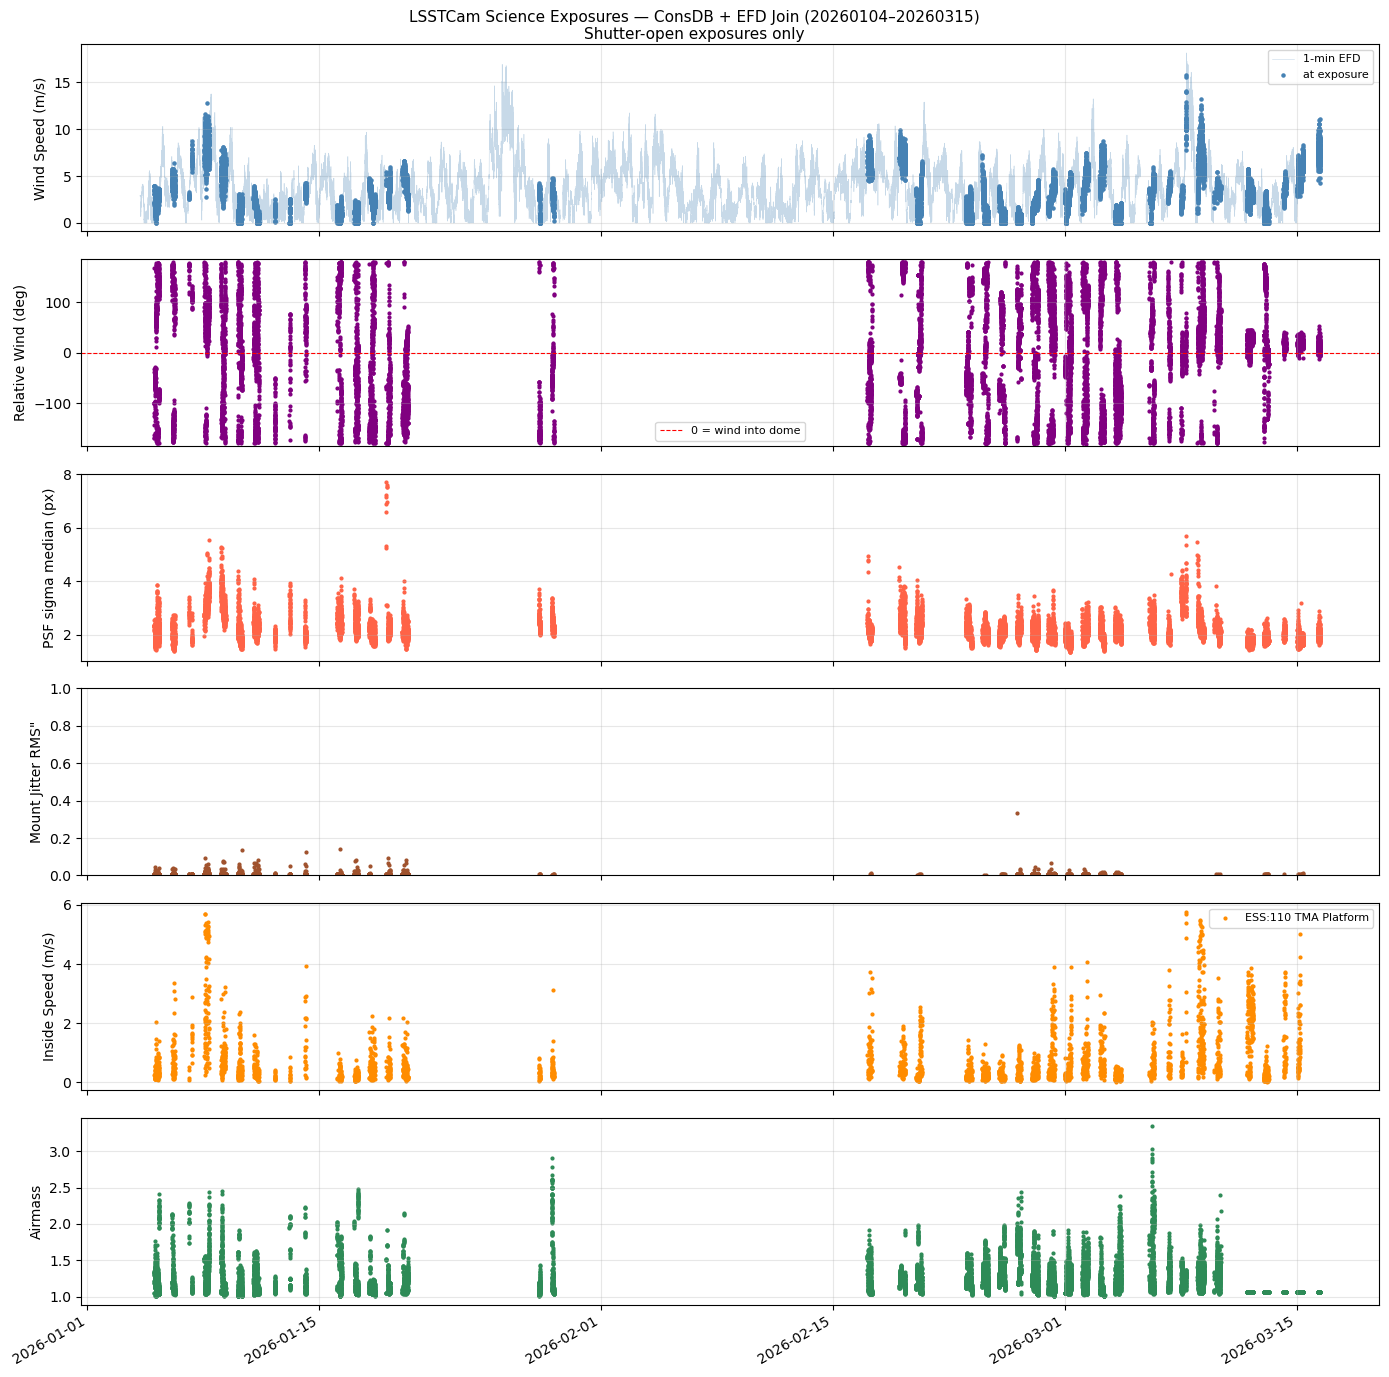

In [77]:
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# Wind speed: 1-min EFD background + ConsDB per-exposure dot
axes[0].plot(df_wind_1m.index, df_wind_1m["efd_wind_speed"],
             lw=0.4, color="steelblue", alpha=0.3, label="1-min EFD")
axes[0].scatter(df_sci.index, df_sci["wind_speed_best"],
                s=5, color="steelblue", label="at exposure")
axes[0].set_ylabel("Wind Speed (m/s)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Relative wind
axes[1].scatter(df_sci_wind.index, df_sci_wind["relative_wind"], s=4, color="purple")
axes[1].axhline(0, color="red", lw=0.8, ls="--", label="0 = wind into dome")
axes[1].set_ylabel("Relative Wind (deg)")
axes[1].set_ylim(-185, 185)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# PSF sigma
df_psf = df_sci.dropna(subset=["psf_sigma_median"])
axes[2].scatter(df_psf.index, df_psf["psf_sigma_median"], s=4, color="tomato")
axes[2].set_ylabel("PSF sigma median (px)")
axes[2].grid(True, alpha=0.3)

# Mount jitter — clip to (0, 1] arcsec (uses MOUNT_JITTER_MIN/MAX from section 8)
df_mnt_ts = df_sci.dropna(subset=["mount_jitter_rms"])
df_mnt_ts = df_mnt_ts[
    (df_mnt_ts["mount_jitter_rms"] > MOUNT_JITTER_MIN) &
    (df_mnt_ts["mount_jitter_rms"] <= MOUNT_JITTER_MAX)
]
axes[3].scatter(df_mnt_ts.index, df_mnt_ts["mount_jitter_rms"], s=4, color="sienna")
axes[3].set_ylabel('Mount Jitter RMS"')
axes[3].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
axes[3].grid(True, alpha=0.3)

# Inside turbulence (TMA platform)
turb_col = "turb_speed_110"
if turb_col in df_sci.columns:
    df_t = df_sci.dropna(subset=[turb_col])
    axes[4].scatter(df_t.index, df_t[turb_col], s=4, color="darkorange",
                    label="ESS:110 TMA Platform")
    axes[4].set_ylabel("Inside Speed (m/s)")
    axes[4].legend(fontsize=8)
    axes[4].grid(True, alpha=0.3)

# Airmass
axes[5].scatter(df_sci.index, df_sci["airmass"], s=4, color="seagreen")
axes[5].set_ylabel("Airmass")
axes[5].grid(True, alpha=0.3)
axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

fig.autofmt_xdate()
fig.suptitle(
    f"LSSTCam Science Exposures — ConsDB + EFD Join ({day_obs_start}–{day_obs_end})\n"
    "Shutter-open exposures only",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 7. Image Quality vs Wind Conditions

PSF σ, effective time, and seeing vs wind speed and relative pointing.

/lscratch/stalder/tmp/ipykernel_903029/1731883921.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


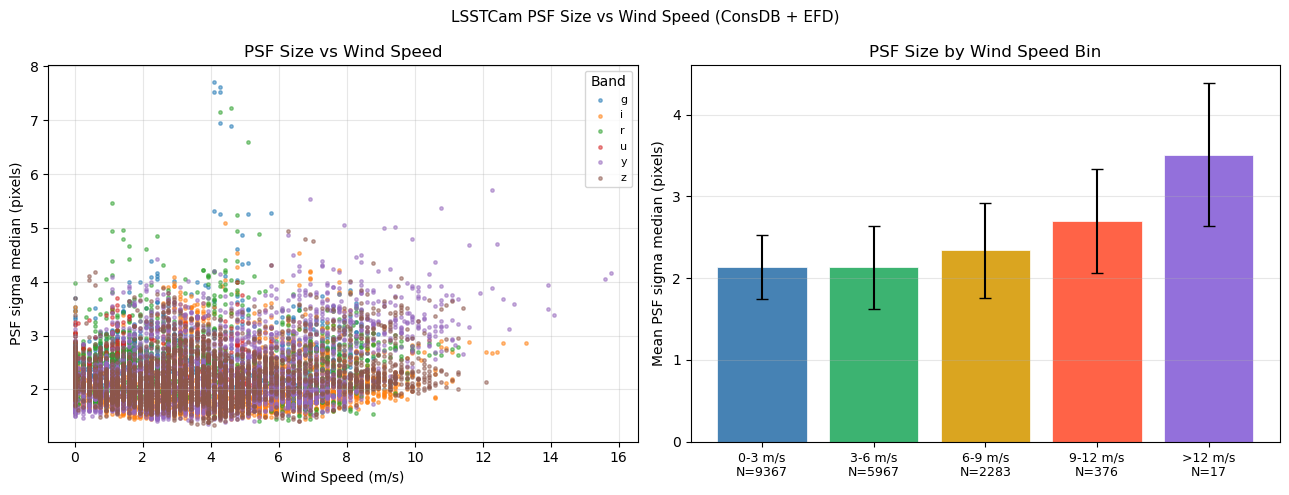

In [78]:
# PSF sigma vs wind speed, binned
df_iq = df_sci_wind.dropna(subset=["psf_sigma_median"]).copy()

if len(df_iq) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: scatter PSF sigma vs wind speed, colored by band
    cmap = plt.cm.get_cmap("tab10")
    bands = df_iq["band"].dropna().unique()
    for i, b in enumerate(sorted(bands)):
        sub = df_iq[df_iq["band"] == b]
        axes[0].scatter(sub["wind_speed_best"], sub["psf_sigma_median"],
                        s=6, alpha=0.5, color=cmap(i), label=b)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("PSF sigma median (pixels)")
    axes[0].legend(title="Band", fontsize=8)
    axes[0].set_title("PSF Size vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    # Right: binned PSF sigma vs wind speed
    by_bin = df_iq.groupby("speed_bin", observed=True)["psf_sigma_median"]
    means  = by_bin.mean()
    stds   = by_bin.std()
    ns     = by_bin.count()
    x_pos  = range(len(means))
    axes[1].bar(x_pos, means, yerr=stds, color=wind_speed_colors[:len(means)],
                capsize=4, edgecolor="white", linewidth=0.5)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([f"{l}\nN={n}" for l, n in zip(means.index, ns)], fontsize=9)
    axes[1].set_ylabel("Mean PSF sigma median (pixels)")
    axes[1].set_title("PSF Size by Wind Speed Bin")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.suptitle("LSSTCam PSF Size vs Wind Speed (ConsDB + EFD)", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No exposures with both PSF sigma and wind data in this window")

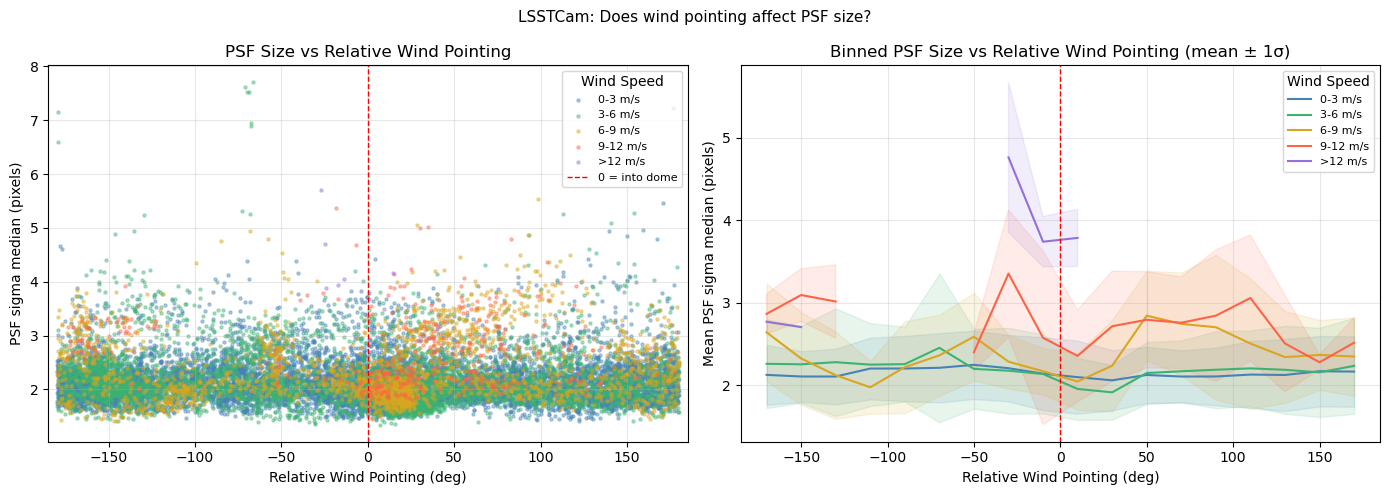

In [79]:
# PSF sigma vs relative wind pointing
if len(df_iq) > 0:
    bin_edges   = np.arange(-180, 181, 20)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter PSF vs relative wind, colored by speed bin
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_iq[df_iq["speed_bin"] == blab]
        axes[0].scatter(sub["relative_wind"], sub["psf_sigma_median"],
                        s=5, alpha=0.4, color=bcol, label=blab)
    axes[0].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[0].set_xlabel("Relative Wind Pointing (deg)")
    axes[0].set_ylabel("PSF sigma median (pixels)")
    axes[0].legend(fontsize=8, title="Wind Speed")
    axes[0].set_xlim(-185, 185)
    axes[0].set_title("PSF Size vs Relative Wind Pointing")
    axes[0].grid(True, alpha=0.3)

    # Right: binned mean PSF vs relative wind, by speed bin
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_iq[df_iq["speed_bin"] == blab].dropna(subset=["relative_wind", "psf_sigma_median"])
        if sub.empty:
            continue
        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        means = [sub.loc[bi == b, "psf_sigma_median"].mean() if (bi == b).any() else np.nan
                 for b in range(len(bin_centers))]
        stds  = [sub.loc[bi == b, "psf_sigma_median"].std()  if (bi == b).any() else np.nan
                 for b in range(len(bin_centers))]
        means, stds = np.array(means), np.array(stds)
        axes[1].plot(bin_centers, means, lw=1.5, color=bcol, label=blab)
        axes[1].fill_between(bin_centers, means - stds, means + stds, alpha=0.12, color=bcol)
    axes[1].axvline(0, color="red", lw=1, ls="--")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel("Mean PSF sigma median (pixels)")
    axes[1].legend(fontsize=8, title="Wind Speed")
    axes[1].set_title("Binned PSF Size vs Relative Wind Pointing (mean ± 1σ)")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("LSSTCam: Does wind pointing affect PSF size?", fontsize=11)
    plt.tight_layout()
    plt.show()

## 7b. Donut Blur and AOS Residual vs Wind Conditions

`donut_blur_fwhm` — FWHM of the PSF blur attributed to out-of-focus donuts (AOS residual wavefront).  
`aos_fwhm` — FWHM of the PSF contribution from the AOS wavefront correction residual.  

Same plot layout as Section 7: scatter + bar by wind speed bin, then scatter + binned by relative wind pointing.

/lscratch/stalder/tmp/ipykernel_903029/3005448592.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


donut_blur_fwhm: 17979 exposures, range [0.5015, 2.9566]


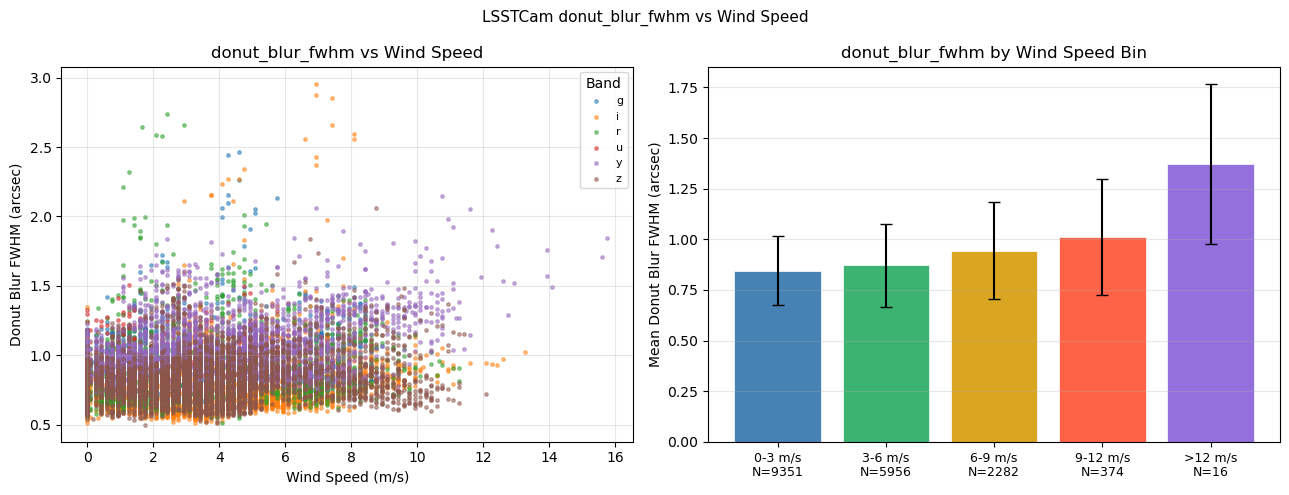

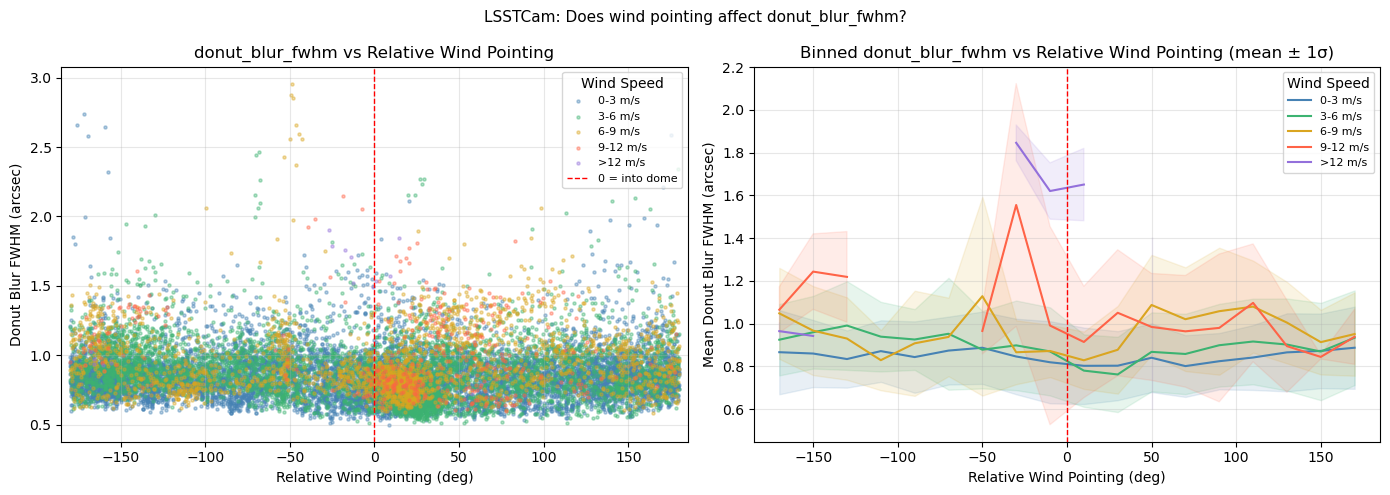

aos_fwhm: 17979 exposures, range [0.3049, 2.2769]


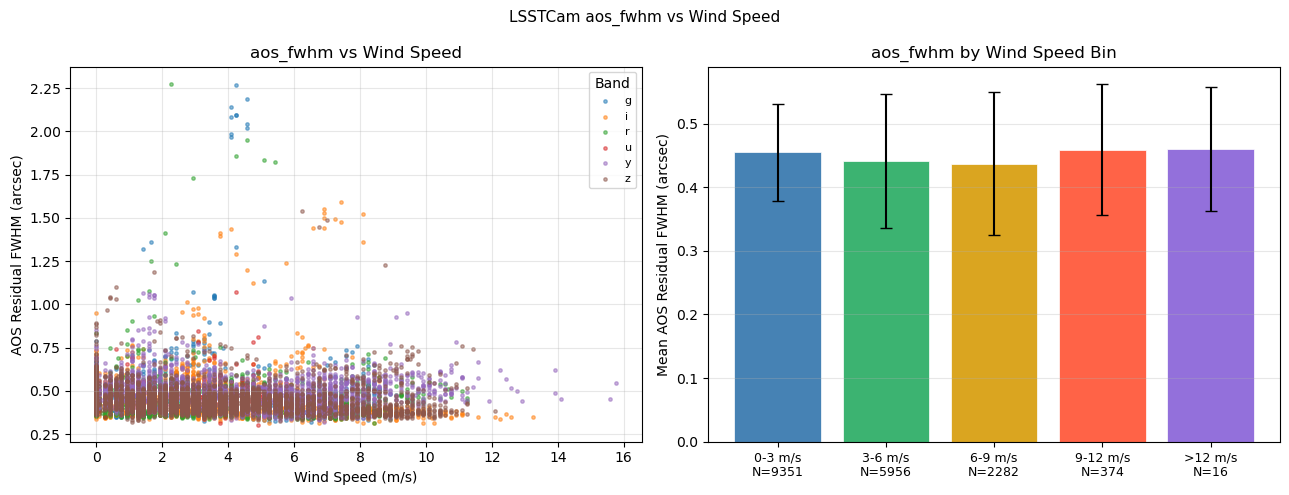

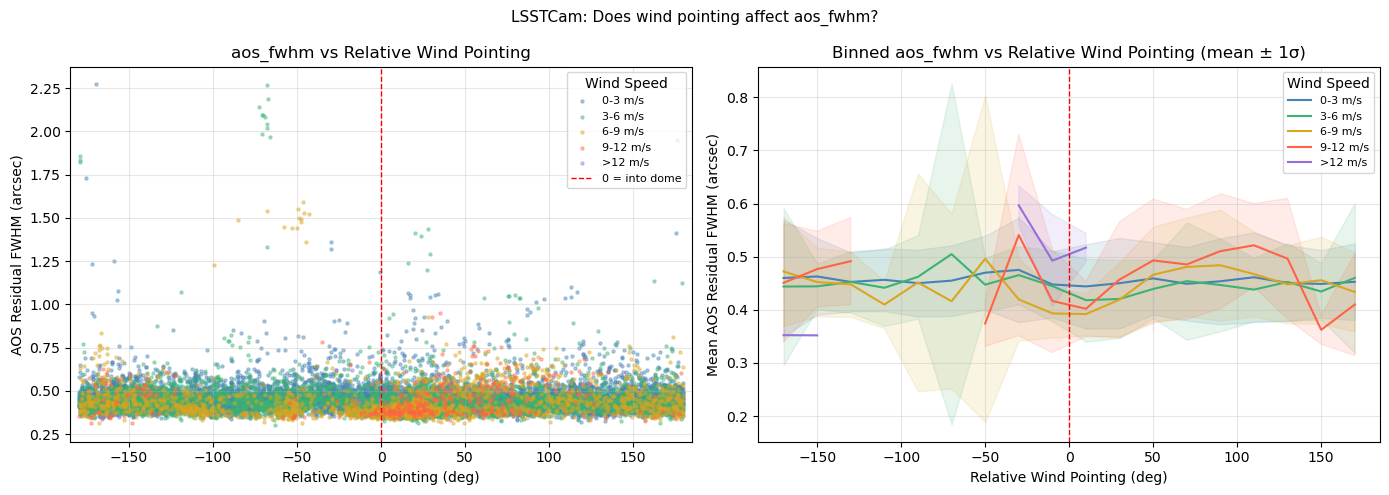

In [80]:
ao_metrics = [
    ("donut_blur_fwhm", "Donut Blur FWHM (arcsec)"),
    ("aos_fwhm",        "AOS Residual FWHM (arcsec)"),
]

# Check which metrics are present — re-run the fetch cell (Section 2) if any are missing
_missing = [col for col, _ in ao_metrics if col not in df_sci_wind.columns]
if _missing:
    print(f"WARNING: columns not in df_sci_wind: {_missing}")
    print("Re-run the ConsDB fetch cell (Section 2) then re-run the join cells before this one.")
    ao_metrics = [(col, lbl) for col, lbl in ao_metrics if col not in _missing]

bin_edges_iq   = np.arange(-180, 181, 20)
bin_centers_iq = 0.5 * (bin_edges_iq[:-1] + bin_edges_iq[1:])
cmap = plt.cm.get_cmap("tab10")

for col, ylabel in ao_metrics:
    df_m = df_sci_wind.dropna(subset=[col]).copy()

    if df_m.empty:
        print(f"{col}: no data in window")
        continue

    print(f"{col}: {len(df_m)} exposures, range [{df_m[col].min():.4f}, {df_m[col].max():.4f}]")

    # ── Plot 1: vs wind speed ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    bands = df_m["band"].dropna().unique()
    for i, b in enumerate(sorted(bands)):
        sub = df_m[df_m["band"] == b]
        axes[0].scatter(sub["wind_speed_best"], sub[col],
                        s=6, alpha=0.5, color=cmap(i), label=b)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Band", fontsize=8)
    axes[0].set_title(f"{col} vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    by_bin = df_m.groupby("speed_bin", observed=True)[col]
    means  = by_bin.mean()
    stds   = by_bin.std()
    ns     = by_bin.count()
    x_pos  = range(len(means))
    axes[1].bar(x_pos, means, yerr=stds, color=wind_speed_colors[:len(means)],
                capsize=4, edgecolor="white", linewidth=0.5)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([f"{l}\nN={n}" for l, n in zip(means.index, ns)], fontsize=9)
    axes[1].set_ylabel(f"Mean {ylabel}")
    axes[1].set_title(f"{col} by Wind Speed Bin")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.suptitle(f"LSSTCam {col} vs Wind Speed", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: vs relative wind pointing ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_m[df_m["speed_bin"] == blab]
        axes[0].scatter(sub["relative_wind"], sub[col],
                        s=5, alpha=0.4, color=bcol, label=blab)
    axes[0].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[0].set_xlabel("Relative Wind Pointing (deg)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=8, title="Wind Speed")
    axes[0].set_xlim(-185, 185)
    axes[0].set_title(f"{col} vs Relative Wind Pointing")
    axes[0].grid(True, alpha=0.3)

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_m[df_m["speed_bin"] == blab].dropna(subset=["relative_wind", col])
        if sub.empty:
            continue
        bi = np.digitize(sub["relative_wind"], bin_edges_iq) - 1
        means = [sub.loc[bi == b, col].mean() if (bi == b).any() else np.nan
                 for b in range(len(bin_centers_iq))]
        stds  = [sub.loc[bi == b, col].std()  if (bi == b).any() else np.nan
                 for b in range(len(bin_centers_iq))]
        means, stds = np.array(means), np.array(stds)
        axes[1].plot(bin_centers_iq, means, lw=1.5, color=bcol, label=blab)
        axes[1].fill_between(bin_centers_iq, means - stds, means + stds,
                             alpha=0.12, color=bcol)
    axes[1].axvline(0, color="red", lw=1, ls="--")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel(f"Mean {ylabel}")
    axes[1].legend(fontsize=8, title="Wind Speed")
    axes[1].set_title(f"Binned {col} vs Relative Wind Pointing (mean ± 1σ)")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LSSTCam: Does wind pointing affect {col}?", fontsize=11)
    plt.tight_layout()
    plt.show()

## 8. Mount Jitter vs Wind

`exposure_quicklook.mount_jitter_rms` and `mount_motion_image_degradation` measure
TMA tracking performance during the shutter-open window.  We test whether wind speed
or relative wind pointing predicts mount jitter.

Mount jitter rows: 5486 total → 5482 after clip (0.0, 1.0] arcsec (removed 4)


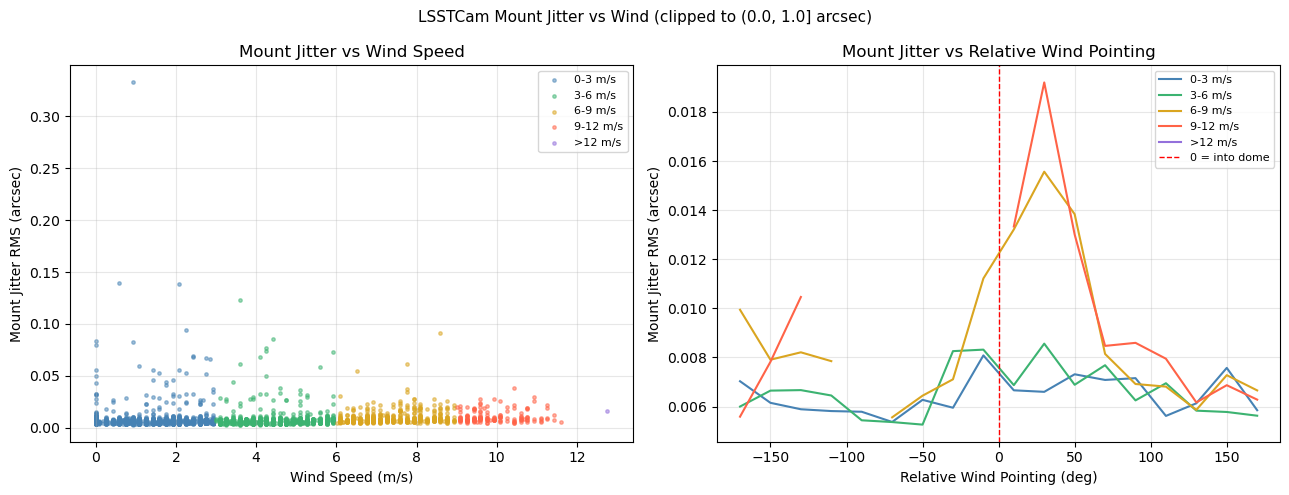

In [83]:
df_mnt_w = df_sci_wind.dropna(subset=["mount_jitter_rms"]).copy()
n_raw = len(df_mnt_w)
df_mnt_w = df_mnt_w[
    (df_mnt_w["mount_jitter_rms"] > MOUNT_JITTER_MIN) &
    (df_mnt_w["mount_jitter_rms"] <= MOUNT_JITTER_MAX)
]
print(f"Mount jitter rows: {n_raw} total → {len(df_mnt_w)} after clip "
      f"({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec "
      f"(removed {n_raw - len(df_mnt_w)})")

if len(df_mnt_w) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: mount jitter vs wind speed
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mnt_w[df_mnt_w["speed_bin"] == blab]
        axes[0].scatter(sub["wind_speed_best"], sub["mount_jitter_rms"],
                        s=6, alpha=0.5, color=bcol, label=blab)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("Mount Jitter RMS (arcsec)")
#    axes[0].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
    axes[0].legend(fontsize=8)
    axes[0].set_title("Mount Jitter vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    # Binned vs relative wind
    bin_edges_rel   = np.arange(-180, 181, 20)
    bin_centers_rel = 0.5 * (bin_edges_rel[:-1] + bin_edges_rel[1:])
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mnt_w[df_mnt_w["speed_bin"] == blab].dropna(subset=["relative_wind"])
        if sub.empty:
            continue
        bi    = np.digitize(sub["relative_wind"], bin_edges_rel) - 1
        means = [sub.loc[bi == b, "mount_jitter_rms"].mean() if (bi == b).any() else np.nan
                 for b in range(len(bin_centers_rel))]
        axes[1].plot(bin_centers_rel, np.array(means), lw=1.5, color=bcol, label=blab)
    axes[1].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel("Mount Jitter RMS (arcsec)")
#    axes[1].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
    axes[1].legend(fontsize=8)
    axes[1].set_title("Mount Jitter vs Relative Wind Pointing")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"LSSTCam Mount Jitter vs Wind (clipped to ({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No mount jitter data in window after clipping")

## 9. Inside Turbulence vs Relative Wind Pointing

Inside wind speed from TMA sensors, joined from EFD — same analysis as
`ESS_Wind_vs_DomePointing.ipynb` but now anchored to actual science exposures
rather than continuous time series.

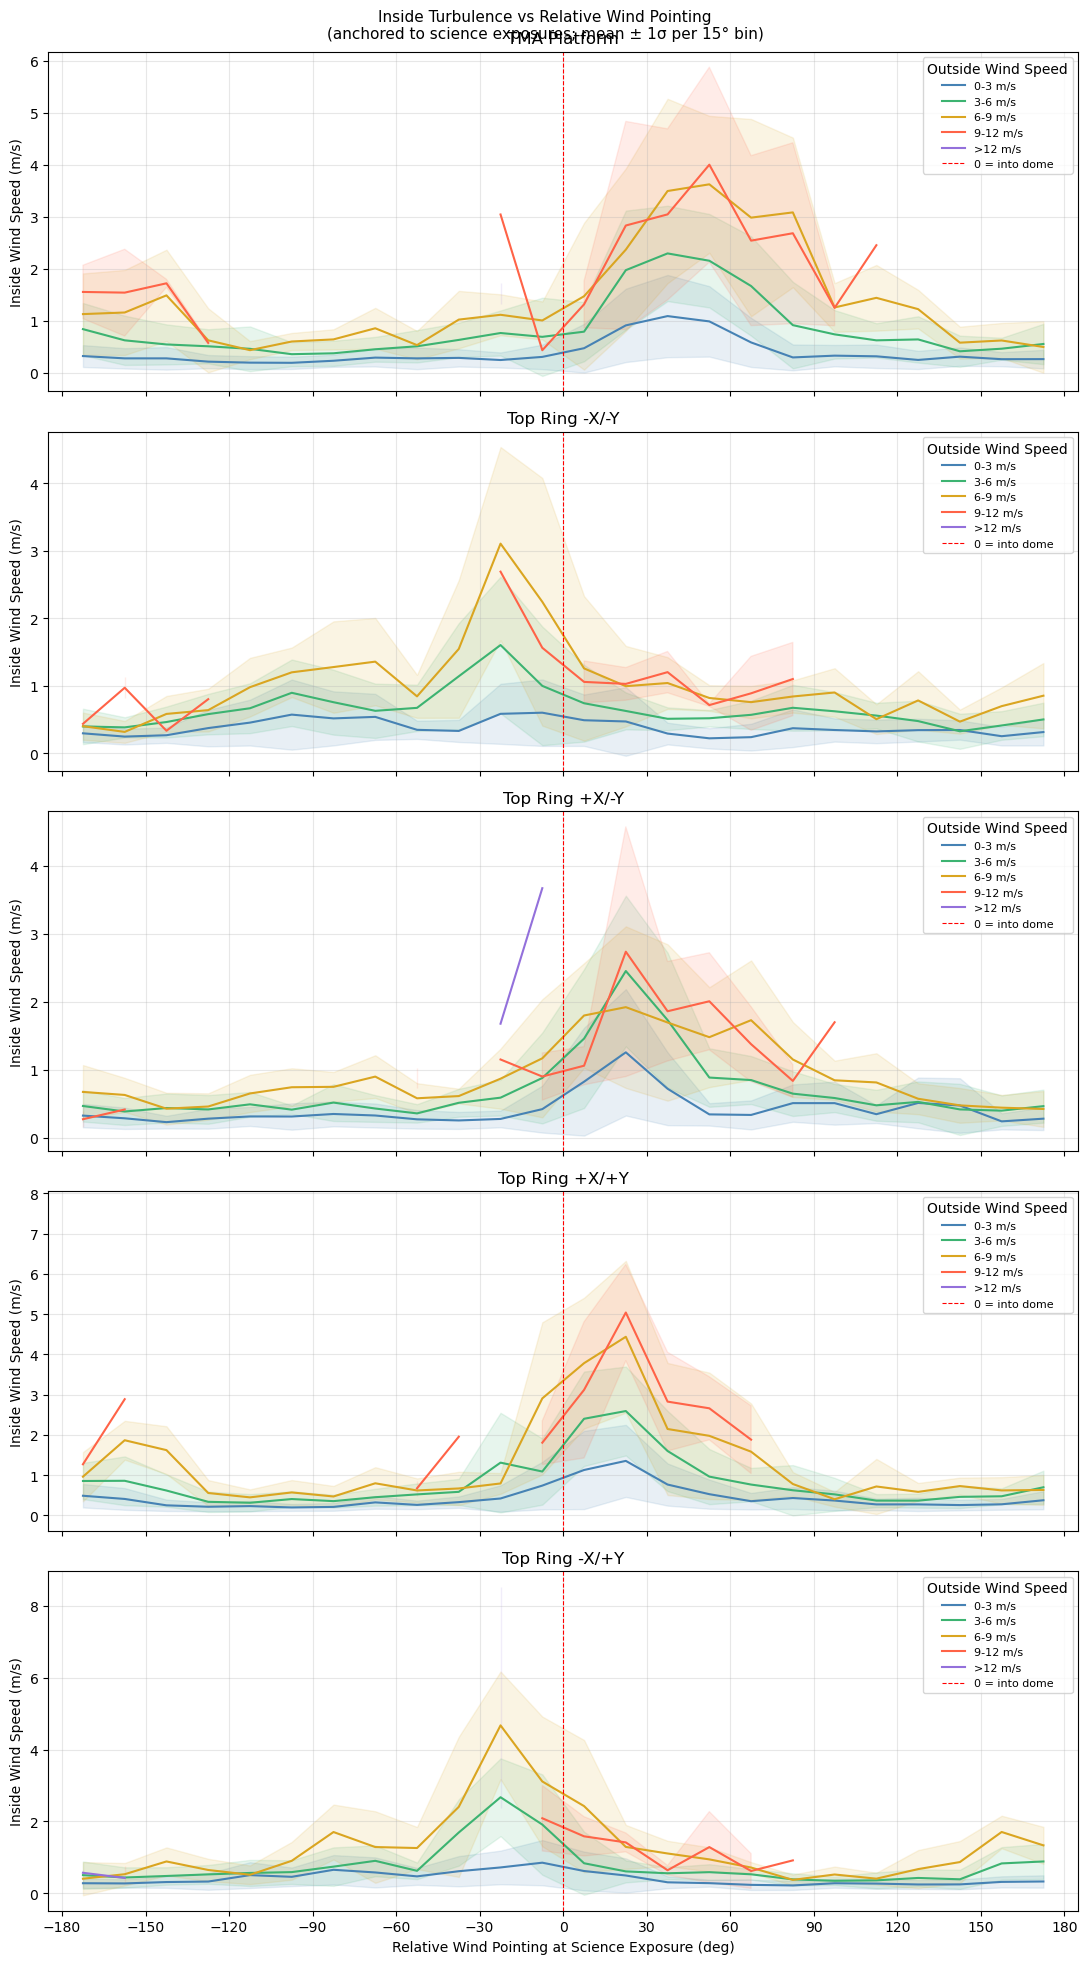

In [84]:
bin_edges_t   = np.arange(-180, 181, 15)
bin_centers_t = 0.5 * (bin_edges_t[:-1] + bin_edges_t[1:])

turb_cols = [(f"turb_speed_{idx}", label) for idx, label in ess_sensors.items()]
turb_cols = [(col, lbl) for col, lbl in turb_cols if col in df_sci_wind.columns]

if turb_cols:
    n_rows = len(turb_cols)
    fig, axes = plt.subplots(n_rows, 1, figsize=(11, 4 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    for ax, (tcol, tlabel) in zip(axes, turb_cols):
        for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
            sub = df_sci_wind[df_sci_wind["speed_bin"] == blab].dropna(
                subset=["relative_wind", tcol]
            )
            if sub.empty:
                continue
            bi    = np.digitize(sub["relative_wind"], bin_edges_t) - 1
            means = [sub.loc[bi == b, tcol].mean() if (bi == b).any() else np.nan
                     for b in range(len(bin_centers_t))]
            stds  = [sub.loc[bi == b, tcol].std()  if (bi == b).any() else np.nan
                     for b in range(len(bin_centers_t))]
            means, stds = np.array(means), np.array(stds)
            ax.plot(bin_centers_t, means, lw=1.5, color=bcol, label=blab)
            ax.fill_between(bin_centers_t, means - stds, means + stds, alpha=0.12, color=bcol)

        ax.axvline(0, color="red", lw=0.8, ls="--", label="0 = into dome")
        ax.set_ylabel("Inside Wind Speed (m/s)")
        ax.set_title(tlabel)
        ax.set_xlim(-185, 185)
        ax.set_xticks(range(-180, 181, 30))
        ax.legend(fontsize=8, title="Outside Wind Speed")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Relative Wind Pointing at Science Exposure (deg)")
    fig.suptitle(
        "Inside Turbulence vs Relative Wind Pointing\n"
        "(anchored to science exposures; mean ± 1σ per 15° bin)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No turbulence columns found in joined table")

## 10. Summary & Next Steps

### What this notebook established

1. **Database**: `usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu / exposurelog`
   has current LSSTCam data (Apr 2025–present) plus `cdb_lsstcomcam`, `cdb_latiss`,
   and star tracker schemas.

2. **ConsDB column names** (lsstcam schema, different from LATISS):
   `img_type='science'`, `obs_start`, `s_ra/s_dec`, `exp_time`, `air_temp`,
   `sky_rotation`.  No `dome_azimuth` — fetch from `lsst.sal.MTDome.azimuth`.

3. **`visit1_quicklook`** provides per-visit PSF σ, effective time, seeing
   (zenith-corrected 500 nm), Zernikes z4–z28, guider FWHM.
   **`exposure_quicklook`** provides mount jitter and image degradation.

4. **EFD join** via `merge_asof` adds dome azimuth, shutter state, inside
   turbulence — anchored to individual science exposures.

### Schema column reference

| Notebook variable | ConsDB column | Notes |
|---|---|---|
| `df_exp["wind_speed"]` | `exposure.wind_speed` | Pre-computed EFD median |
| `df_exp["dome_azimuth_efd"]` | *(from EFD)* | Interp from MTDome.azimuth |
| `df_exp["psf_sigma_median"]` | `visit1_quicklook.psf_sigma_median` | |
| `df_exp["mount_jitter_rms"]` | `exposure_quicklook.mount_jitter_rms` | |
| `df_exp["turb_speed_110"]` | *(from EFD)* | ESS:110 TMA Platform |

### Potential follow-on analyses

| Question | Required columns |
|---|---|
| Does `relative_wind` predict PSF size? | `psf_sigma_median` + `dome_azimuth_efd` |
| Does wind speed predict mount jitter? | `mount_jitter_rms` + `wind_speed` |
| Is there a preferred dome pointing angle? | `relative_wind` + `eff_time_median` |
| Correlate Zernikes with turbulence? | `z4`–`z11` + `turb_speed_*` |
| Compare summit vs USDF seeing? | `dimm_seeing` + `seeing_zenith_500nm_median` |